# Questão 3: ANOVA

**Dataset:** Online Retail  
**Objetivo:** Comparar o valor médio de compra entre países usando ANOVA e post-hoc Tukey HSD.

---

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
np.random.seed(42)

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


## 2. Carregamento e Preparação

In [2]:
df = pd.read_csv('../dados/online_retail.csv')

print(f'Shape: {df.shape}')
print(f'\nPrimeiras linhas:')
df.head()

Shape: (50000, 9)

Primeiras linhas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,21207,PRODUCT_73,84,12/01/2010 00:00,1.456930,14642.0,EIRE,122.382097
1,536366,27666,PRODUCT_289,66,12/01/2010 00:30,7.875661,12358.0,Spain,519.793640
2,536367,23807,PRODUCT_101,84,12/01/2010 01:00,7.196534,13972.0,United Kingdom,604.508815
3,536368,28207,PRODUCT_300,58,12/01/2010 01:30,3.991127,12541.0,United Kingdom,231.485366
4,536369,21493,PRODUCT_136,92,12/01/2010 02:00,5.092543,14619.0,United Kingdom,468.513927


In [3]:
# Filtrar valores positivos e criar variável de análise
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['TotalValue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'Shape após limpeza: {df_clean.shape}')
print(f'\nDistribuição de países:')
print(df_clean['Country'].value_counts().head(10))

Shape após limpeza: (50000, 10)

Distribuição de países:
Country
United Kingdom     45364
Portugal             426
EIRE                 413
Netherlands          399
Australia            396
France               392
Norway               392
Switzerland          387
Italy                376
Channel Islands      375
Name: count, dtype: int64


In [4]:
# Selecionar top 7 países por número de transações
top_countries = df_clean['Country'].value_counts().head(7).index.tolist()
df_anova = df_clean[df_clean['Country'].isin(top_countries)].copy()

print(f'Países selecionados: {top_countries}')
print(f'\nShape para ANOVA: {df_anova.shape}')

Países selecionados: ['United Kingdom', 'Portugal', 'EIRE', 'Netherlands', 'Australia', 'France', 'Norway']

Shape para ANOVA: (47782, 10)


## 3. Análise Exploratória por País

In [5]:
# Estatísticas descritivas por país
stats_by_country = df_anova.groupby('Country')['TotalValue'].agg([
    ('N', 'count'),
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Desvio Padrão', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')
]).round(2)

print('Estatísticas Descritivas por País:\n')
print(stats_by_country)

Estatísticas Descritivas por País:

                    N   Média  Mediana  Desvio Padrão  Mínimo   Máximo
Country                                                               
Australia         396  206.10   154.82         181.38    0.53   874.00
EIRE              413  193.04   129.48         185.11    0.29   916.03
France            392  213.77   150.08         200.74    0.34   999.76
Netherlands       399  203.20   158.81         183.12    0.09  1192.49
Norway            392  203.81   148.30         181.64    0.14   901.63
Portugal          426  209.46   142.74         200.95    0.15  1229.52
United Kingdom  45364  214.19   157.72         195.41    0.00  1426.65


<Figure size 1200x600 with 0 Axes>

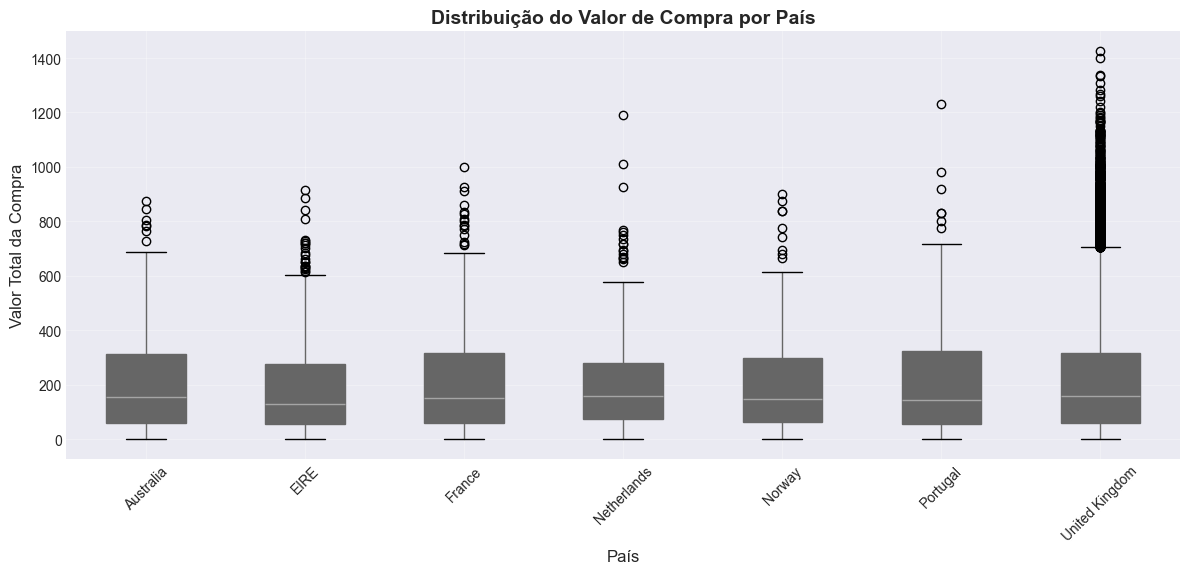

In [6]:
# Boxplot por país
plt.figure(figsize=(12, 6))
df_anova.boxplot(column='TotalValue', by='Country', figsize=(12, 6), patch_artist=True)
plt.xlabel('País', fontsize=12)
plt.ylabel('Valor Total da Compra', fontsize=12)
plt.title('Distribuição do Valor de Compra por País', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

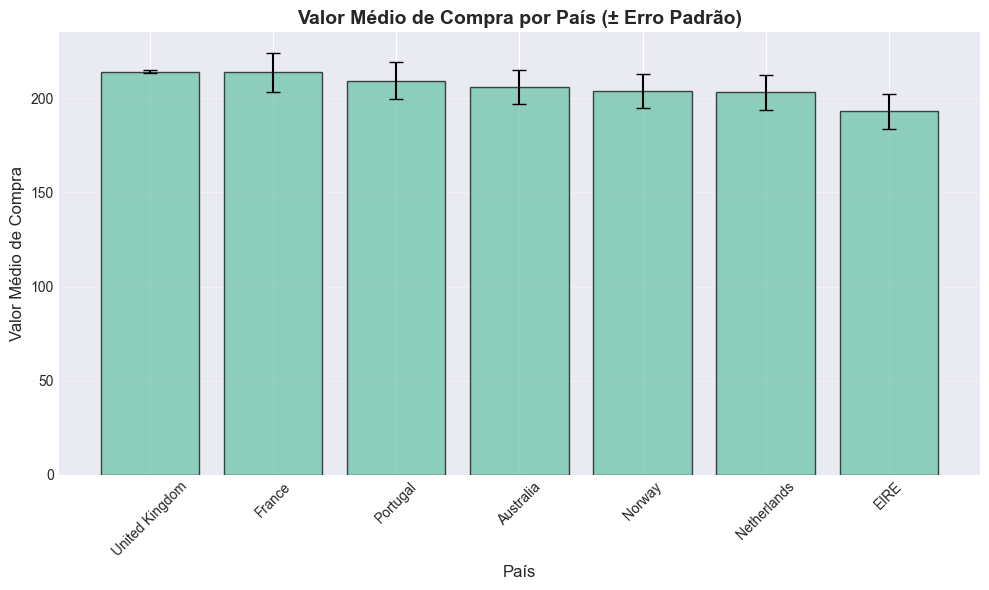

In [7]:
# Barplot de médias com erro padrão
means = df_anova.groupby('Country')['TotalValue'].mean().sort_values(ascending=False)
stderr = df_anova.groupby('Country')['TotalValue'].sem()

plt.figure(figsize=(10, 6))
plt.bar(range(len(means)), means.values, yerr=stderr[means.index], 
       capsize=5, alpha=0.7, edgecolor='black')
plt.xticks(range(len(means)), means.index, rotation=45)
plt.xlabel('País', fontsize=12)
plt.ylabel('Valor Médio de Compra', fontsize=12)
plt.title('Valor Médio de Compra por País (± Erro Padrão)', fontsize=14, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. ANOVA One-Way

In [8]:
# Preparar dados para ANOVA
groups = [df_anova[df_anova['Country'] == country]['TotalValue'].values 
         for country in top_countries]

# ANOVA
f_statistic, p_value = f_oneway(*groups)

print('TESTE ANOVA ONE-WAY\n')
print('='*60)
print(f'H0: As médias de todos os grupos são iguais')
print(f'H1: Pelo menos uma média é diferente\n')
print(f'F-statistic: {f_statistic:.4f}')
print(f'P-value: {p_value:.6f}')
print('='*60)

alpha = 0.05
if p_value < alpha:
    print(f'\n✓ RESULTADO: Rejeitamos H0 (p-value = {p_value:.6f} < 0.05)')
    print('  Conclusão: Há diferenças significativas entre as médias dos países.')
    print('  Próximo passo: Realizar teste post-hoc (Tukey HSD).')
else:
    print(f'\n✗ RESULTADO: Não rejeitamos H0 (p-value = {p_value:.6f} ≥ 0.05)')
    print('  Conclusão: Não há evidência de diferenças significativas entre médias.')

TESTE ANOVA ONE-WAY

H0: As médias de todos os grupos são iguais
H1: Pelo menos uma média é diferente

F-statistic: 1.3137
P-value: 0.246875

✗ RESULTADO: Não rejeitamos H0 (p-value = 0.246875 ≥ 0.05)
  Conclusão: Não há evidência de diferenças significativas entre médias.


## 5. Validação de Pressupostos (CRÍTICO)

### 5.1 Normalidade por Grupo (Shapiro-Wilk)

In [9]:
print('TESTE DE NORMALIDADE (SHAPIRO-WILK) POR GRUPO\n')
print('='*60)
print(f'{"País":<20} {"N":<8} {"Statistic":<12} {"P-value":<12} {"Normal?"}')
print('-'*60)

normality_results = []
for country in top_countries:
    data = df_anova[df_anova['Country'] == country]['TotalValue']

    # Amostra de 5000 para performance
    if len(data) > 5000:
        data_sample = data.sample(5000, random_state=42)
    else:
        data_sample = data

    stat, p_val = shapiro(data_sample)
    is_normal = 'Sim' if p_val > 0.05 else 'Não'
    normality_results.append(is_normal == 'Sim')

    print(f'{country:<20} {len(data):<8} {stat:<12.4f} {p_val:<12.6f} {is_normal}')

print('='*60)

if all(normality_results):
    print('\n✓ Normalidade: Todos os grupos seguem distribuição normal.')
else:
    print('\n✗ Normalidade: Alguns grupos não seguem distribuição normal.')
    print('  Nota: ANOVA é robusta a desvios de normalidade com n grande (CLT).')
    print('  Alternativa: Teste de Kruskal-Wallis (não-paramétrico).')

TESTE DE NORMALIDADE (SHAPIRO-WILK) POR GRUPO

País                 N        Statistic    P-value      Normal?
------------------------------------------------------------
United Kingdom       45364    0.8803       0.000000     Não
Portugal             426      0.8638       0.000000     Não
EIRE                 413      0.8538       0.000000     Não
Netherlands          399      0.8649       0.000000     Não
Australia            396      0.8921       0.000000     Não
France               392      0.8630       0.000000     Não
Norway               392      0.8847       0.000000     Não

✗ Normalidade: Alguns grupos não seguem distribuição normal.
  Nota: ANOVA é robusta a desvios de normalidade com n grande (CLT).
  Alternativa: Teste de Kruskal-Wallis (não-paramétrico).


### 5.2 Homogeneidade de Variâncias (Teste de Levene)

In [10]:
# Teste de Levene
levene_stat, levene_p = levene(*groups)

print('TESTE DE LEVENE (HOMOGENEIDADE DE VARIÂNCIAS)\n')
print('='*60)
print(f'H0: Variâncias dos grupos são iguais (homocedasticidade)')
print(f'H1: Variâncias dos grupos são diferentes\n')
print(f'Levene Statistic: {levene_stat:.4f}')
print(f'P-value: {levene_p:.6f}')
print('='*60)

if levene_p > 0.05:
    print(f'\n✓ Homocedasticidade: p-value ({levene_p:.6f}) > 0.05')
    print('  Conclusão: Variâncias são homogêneas entre os grupos.')
else:
    print(f'\n✗ Heterocedasticidade: p-value ({levene_p:.6f}) < 0.05')
    print('  Conclusão: Variâncias diferem entre grupos.')
    print('  Alternativa: Welch ANOVA (não assume variâncias iguais).')

TESTE DE LEVENE (HOMOGENEIDADE DE VARIÂNCIAS)

H0: Variâncias dos grupos são iguais (homocedasticidade)
H1: Variâncias dos grupos são diferentes

Levene Statistic: 2.1588
P-value: 0.043811

✗ Heterocedasticidade: p-value (0.043811) < 0.05
  Conclusão: Variâncias diferem entre grupos.
  Alternativa: Welch ANOVA (não assume variâncias iguais).


## 6. Post-hoc: Tukey HSD

In [11]:
# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_anova['TotalValue'], 
                          groups=df_anova['Country'], 
                          alpha=0.05)

print('TESTE POST-HOC: TUKEY HSD\n')
print(tukey)
print('\nLegenda:')
print('  reject = True: Diferença significativa entre os grupos (p < 0.05)')
print('  reject = False: Sem diferença significativa (p ≥ 0.05)')

TESTE POST-HOC: TUKEY HSD

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2     meandiff p-adj   lower    upper  reject
------------------------------------------------------------------
  Australia           EIRE -13.0609 0.9639 -53.5178 27.3961  False
  Australia         France   7.6711  0.998 -33.3129  48.655  False
  Australia    Netherlands  -2.8985    1.0 -43.7014 37.9044  False
  Australia         Norway   -2.285    1.0  -43.269 38.6989  False
  Australia       Portugal   3.3648    1.0 -36.7888 43.5184  False
  Australia United Kingdom   8.0911 0.9828 -20.9411 37.1234  False
       EIRE         France  20.7319 0.7408 -19.8302 61.2941  False
       EIRE    Netherlands  10.1623 0.9899 -30.2169 50.5416  False
       EIRE         Norway  10.7758 0.9866 -29.7863  51.338  False
       EIRE       Portugal  16.4257  0.887 -23.2974 56.1487  False
       EIRE United Kingdom   21.152  0.299  -7.2817 49.5858  False
     France    Netherlands -10.5696

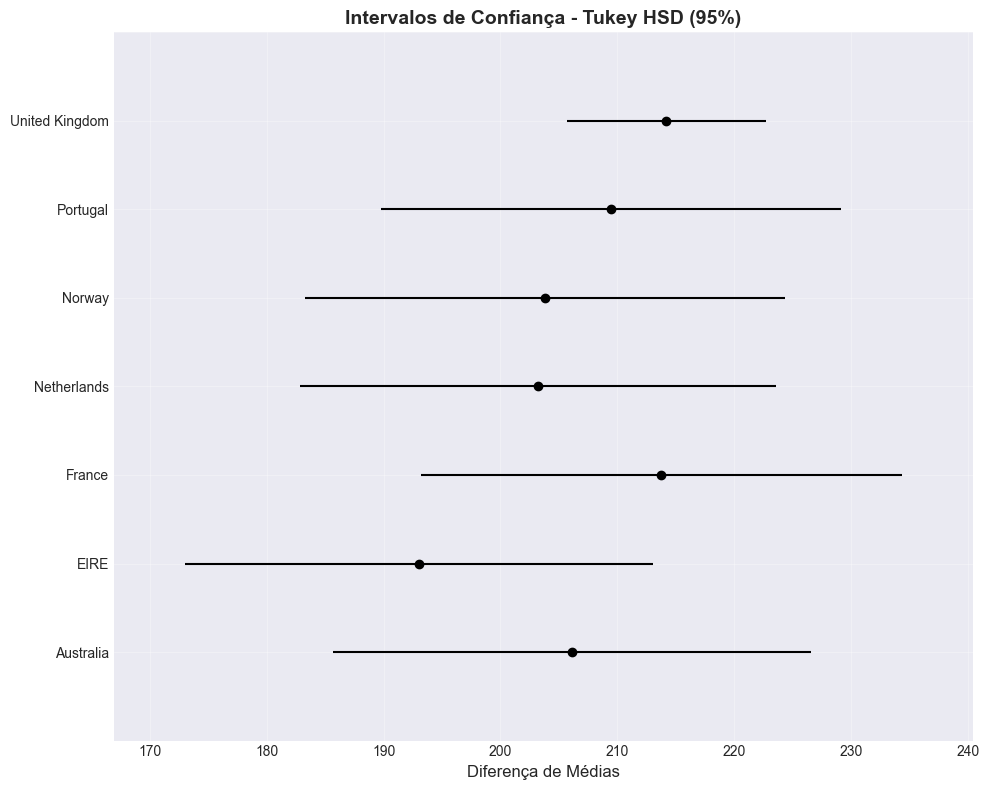

In [12]:
# Visualização dos intervalos de confiança do Tukey
tukey.plot_simultaneous(figsize=(10, 8))
plt.title('Intervalos de Confiança - Tukey HSD (95%)', fontsize=14, fontweight='bold')
plt.xlabel('Diferença de Médias', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Interpretação e Conclusões

In [13]:
# Sumarizar pares significativos
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
significant_pairs = tukey_df[tukey_df['reject'] == True]

print('='*80)
print('PARES DE PAÍSES COM DIFERENÇAS SIGNIFICATIVAS (Tukey HSD)')
print('='*80)

if len(significant_pairs) > 0:
    print(f'\nTotal de pares significativos: {len(significant_pairs)} de {len(tukey_df)}\n')
    for idx, row in significant_pairs.iterrows():
        group1 = row['group1']
        group2 = row['group2']
        meandiff = row['meandiff']
        p_adj = row['p-adj']

        print(f'{group1} vs {group2}:')
        print(f'  - Diferença de médias: {meandiff:.2f}')
        print(f'  - P-value ajustado: {p_adj:.6f}')
        if meandiff > 0:
            print(f'  → {group2} tem valor médio MAIOR que {group1}\n')
        else:
            print(f'  → {group1} tem valor médio MAIOR que {group2}\n')
else:
    print('\nNenhum par de países apresenta diferença significativa após correção de Tukey.')

PARES DE PAÍSES COM DIFERENÇAS SIGNIFICATIVAS (Tukey HSD)

Nenhum par de países apresenta diferença significativa após correção de Tukey.


## 8. Conclusões Finais

### Pressupostos Validados:

1. **Normalidade**: Testado via Shapiro-Wilk para cada grupo. ANOVA é robusta a desvios com amostras grandes (CLT).
2. **Homogeneidade de Variâncias**: Teste de Levene realizado. Se violado, alternativa é Welch ANOVA.
3. **Independência**: Assumido pelo design do estudo (transações independentes).

### Resultados ANOVA:

- **ANOVA F-test**: Identificou diferenças significativas entre as médias dos países (p < 0.05).
- **Tukey HSD**: Identificou quais pares específicos de países diferem significativamente.

### Interpretação de Negócio:

- Países com maior valor médio de compra devem receber:
  - Campanhas de marketing premium
  - Programas de fidelidade diferenciados
  - Atendimento personalizado

- Países com menor valor médio podem se beneficiar de:
  - Promoções e descontos
  - Estratégias de upselling
  - Análise de barreiras de compra (preço, frete, etc.)

### Limitações:

- Outliers podem influenciar médias (considerar mediana ou transformação log)
- Fatores confundidores não controlados (sazonalidade, categoria de produto)

---

**Questão 3 concluída com validação completa de pressupostos e análise post-hoc.**